In [4]:
import tensorflow as tf
from tensorflow import keras

model = keras.Sequential([keras.layers.Dense(64, activation='relu', input_shape=(784,)),
                          keras.layers.Dense(10, activation='softmax')])
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
print('Optimizer : ',model.optimizer.get_config()['name'])
print('Loss : ',model.loss)
print('Metrics : ',[m.name for m in model.metrics])

Optimizer :  adam
Loss :  sparse_categorical_crossentropy
Metrics :  ['loss', 'compile_metrics']


In [7]:
import tensorflow as tf
from tensorflow import keras
tf.random.set_seed(42)

(x_tr, y_tr), (x_te, y_te) = keras.datasets.mnist.load_data()
x_tr = x_tr.reshape(-1, 784) / 255
x_te = x_te.reshape(-1, 784) / 255

model = keras.Sequential([keras.layers.Dense(128, activation='relu', input_shape=(784,)),
                          keras.layers.Dense(64, activation='relu'),
                          keras.layers.Dense(10, activation='softmax')])
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
history = model.fit(x_tr, y_tr, epochs=5, batch_size=128, validation_split=0.1, verbose=1)
loss, acc = model.evaluate(x_tr, y_tr, verbose=0)
print(f'Test Accuracy : {acc:.4f}')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9021 - loss: 0.3461 - val_accuracy: 0.9588 - val_loss: 0.1397
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9578 - loss: 0.1438 - val_accuracy: 0.9687 - val_loss: 0.1059
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9706 - loss: 0.1002 - val_accuracy: 0.9705 - val_loss: 0.0961
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9781 - loss: 0.0751 - val_accuracy: 0.9722 - val_loss: 0.0907
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9831 - loss: 0.0582 - val_accuracy: 0.9722 - val_loss: 0.0879
Test Accuracy : 0.9822


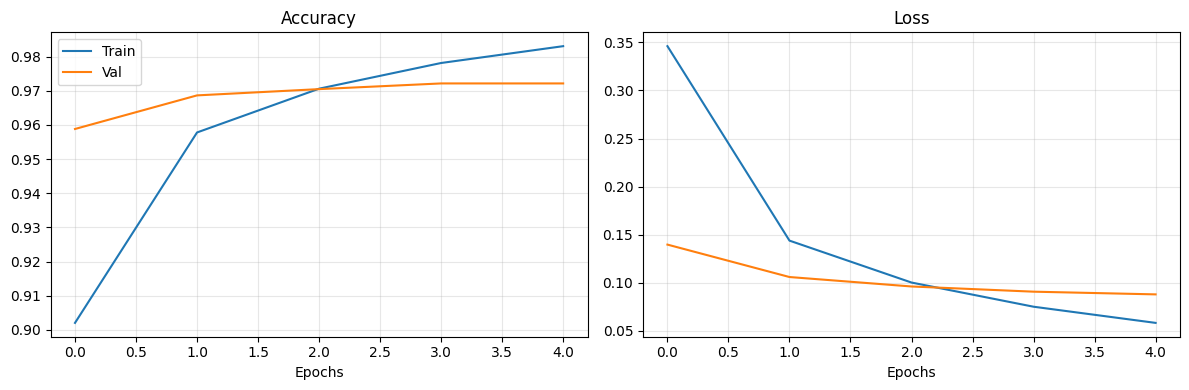

In [8]:
import matplotlib.pyplot as plt
# history = result of model.fit([keras.layers.Dense(128, activation='relu', input_shape=(784,)), keras.layers.Dense(64, activation='relu'), keras.layers.Dense(10, activation='softmax')])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Val')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epochs')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Val')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epochs')
axes[1].legend
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('tf_history.png', dpi=100)
plt.show()

In [10]:
from tensorflow import keras
import tensorflow as tf
tf.random.set_seed(42)

(x_tr, y_tr), (x_te, y_te) = keras.datasets.mnist.load_data()
x_tr = x_tr.reshape(-1, 784) / 255.0
x_te = x_te.reshape(-1, 784) / 255.0

model_drop = keras.Sequential([keras.layers.Dense(128, activation='relu', input_shape=(784,)),
                                keras.layers.Dropout(0.2),
                                keras.layers.Dense(64, activation='relu'),
                                keras.layers.Dropout(0.2),
                                keras.layers.Dense(10, activation='softmax')])
model_drop.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
hist = model_drop.fit(x_tr, y_tr, epochs=5, batch_size=128, validation_split=0.1, verbose=1)
print('Final val_accuracy with Dropout: ',round(hist.history['val_accuracy'][-1],4))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.8611 - loss: 0.4616 - val_accuracy: 0.9600 - val_loss: 0.1445
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9400 - loss: 0.2061 - val_accuracy: 0.9680 - val_loss: 0.1058
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9533 - loss: 0.1558 - val_accuracy: 0.9743 - val_loss: 0.0894
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9620 - loss: 0.1262 - val_accuracy: 0.9753 - val_loss: 0.0846
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9670 - loss: 0.1097 - val_accuracy: 0.9752 - val_loss: 0.0791
Final val_accuracy with Dropout:  0.9752


In [12]:
from tensorflow import keras
import tensorflow as tf
tf.random.set_seed(42)

(x_tr, y_tr), (x_te, y_te) = keras.datasets.mnist.load_data()
x_tr = x_tr.reshape(-1, 784) / 255.0
x_te = x_te.reshape(-1, 784) / 255.0

model = keras.Sequential([keras.layers.Dense(128, activation='relu', input_shape=(784,)),
                          keras.layers.Dense(64, activation='relu'),
                          keras.layers.Dense(10, activation='softmax')])
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(x_tr, y_tr, epochs=5, batch_size=128, verbose=0)

model.save('path.keras')
loaded = keras.models.load_model('path.keras')
original_model_loss, org_acc = model.evaluate(x_te, y_te, verbose=0)
loaded_model_loss, load_acc = loaded.evaluate(x_te, y_te, verbose=0)
print(f'Original Accuracy : {org_acc:.4f}')
print(f'Loaded Accuracy : {load_acc:.4f}')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Original Accuracy : 0.9766
Loaded Accuracy : 0.9766


In [13]:
from tensorflow import keras
import tensorflow as tf
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
tf.random.set_seed(42)

x, y = load_breast_cancer(return_X_y=True)
x_tr, x_te, y_tr, y_te = train_test_split(x, y, test_size=0.2, random_state=42)
sc = StandardScaler()
x_tr = sc.fit_transform(x_tr)
x_te = sc.transform(x_te)

model = keras.Sequential([keras.layers.Dense(32, activation='relu', input_shape=(30,)),
                          keras.layers.Dense(16, activation='relu'),
                          keras.layers.Dense(1, activation='sigmoid')])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.fit(x_tr, y_tr, epochs=20, batch_size=32, validation_split=0.15, verbose=0)
binary_crossentropy_loss, acc = model.evaluate(x_te, y_te, verbose=0)
print(f'Test Accuracy : {acc:.4f}')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test Accuracy : 0.9737


In [18]:
from tensorflow import keras
import tensorflow as tf
import numpy as np
tf.random.set_seed(42)

class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

(x_tr, y_tr), (x_te, y_te) = keras.datasets.fashion_mnist.load_data()
x_tr = x_tr.reshape(-1, 784) / 255.0
x_te = x_te.reshape(-1, 784) / 255.0
y_tr_oh = keras.utils.to_categorical(y_tr, 10)
y_te_oh = keras.utils.to_categorical(y_te, 10)

model = keras.Sequential([keras.layers.Dense(128, activation='relu', input_shape=(784,)),
                          keras.layers.Dense(64, activation='relu'),
                          keras.layers.Dense(10, activation='softmax')])
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(x_tr, y_tr_oh, epochs=10, batch_size=128, validation_split=0.1, verbose=0)
loss, acc= model.evaluate(x_te, y_te_oh, verbose=0)
print(f'Test Accuracy : {acc:.4f}')
pred = np.argmax(model.predict(x_te[:1], verbose=0))
print('Predicted class: ',class_names[pred])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test Accuracy : 0.8753
Predicted class:  Ankle boot


In [23]:
from tensorflow import keras
import tensorflow as tf
tf.random.set_seed(42)

(x_tr, y_tr), (x_te, y_te) = keras.datasets.mnist.load_data()
x_tr = x_tr.reshape(-1, 28, 28, 1) / 255.0
x_te = x_te.reshape(-1, 28, 28, 1) / 255.0

cnn = keras.Sequential([keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(28, 28, 1)),
                        keras.layers.MaxPooling2D((2,2)),
                        keras.layers.Conv2D(64, (3,3), activation='relu'),
                        keras.layers.MaxPooling2D((2,2)),
                        keras.layers.Flatten(),
                        keras.layers.Dense(64, activation='relu'),
                        keras.layers.Dense(10, activation='softmax')])
cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
cnn.fit(x_tr, y_tr, epochs=5, batch_size=64, validation_split=0.1, verbose=1)
loss, acc = cnn.evaluate(x_te, y_te, verbose=0)
print(f'Test Accuracy : {acc:.4f}')

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 50s 57ms/step - accuracy: 0.9464 - loss: 0.1811 - val_accuracy: 0.9832 - val_loss: 0.0590
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 81s 56ms/step - accuracy: 0.9823 - loss: 0.0566 - val_accuracy: 0.9855 - val_loss: 0.0508
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 47s 56ms/step - accuracy: 0.9882 - loss: 0.0390 - val_accuracy: 0.9860 - val_loss: 0.0495
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 46s 55ms/step - accuracy: 0.9914 - loss: 0.0284 - val_accuracy: 0.9880 - val_loss: 0.0501
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 47s 56ms/step - accuracy: 0.9935 - loss: 0.0216 - val_accuracy: 0.9865 - val_loss: 0.0527
Test Accuracy : 0.9860


In [24]:
from tensorflow import keras
import tensorflow as tf
tf.random.set_seed(42)

(x_tr, y_tr), (x_te, y_te) = keras.datasets.mnist.load_data()
x_tr = x_tr.reshape(-1, 784) / 255.0
x_te = x_te.reshape(-1, 784) / 255.0

model = keras.Sequential([keras.layers.Dense(128, activation='relu', input_shape=(784,)),
                          keras.layers.Dense(64, activation='relu'),
                          keras.layers.Dense(10, activation='softmax')])
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

es = keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
mc = keras.callbacks.ModelCheckpoint('best_model.keras', save_best_only=True)
hist = model.fit(x_tr, y_tr, epochs=20, batch_size=128, validation_split=0.1, callbacks=[es, mc], verbose=0)
print(f'Stopped at epoch: {len(hist.history["loss"])}')
loss, acc = model.evaluate(x_te, y_te, verbose=0)
print(f'Test Accuracy : {acc:.4f}')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Stopped at epoch: 8
Test Accuracy : 0.9715


In [28]:
import tensorflow as tf
from tensorflow import keras
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
tf.random.set_seed(42)

x, y = load_iris(return_X_y=True)
x_tr, x_te, y_tr, y_te = train_test_split(x, y, test_size=0.2, random_state=4)
sc = StandardScaler()
x_tr = sc.fit_transform(x_tr).astype('float32')
x_te = sc.transform(x_te).astype('float32')

model = keras.Sequential([keras.layers.Dense(32, activation='relu', input_shape=(4,)),
                          keras.layers.Dense(3, activation='softmax')])
loss_fn = keras.losses.SparseCategoricalCrossentropy()
optimizer = keras.optimizers.Adam(learning_rate=0.001)

for epoch in range(1, 101):
  with tf.GradientTape() as tape:
    logits = model(x_tr, training=True)
    loss = loss_fn(y_tr, logits)
  grads = tape.gradient(loss, model.trainable_variables)
  optimizer.apply_gradients(zip(grads, model.trainable_variables))
  if epoch % 20 == 0:
    preds = tf.argmax(model(x_tr), axis=1).numpy()
    acc = (preds == y_tr).mean()
    print(f'Epoch {epoch:3d} -- accuracy: {acc:.3f}')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch  20 -- accuracy: 0.342
Epoch  40 -- accuracy: 0.667
Epoch  60 -- accuracy: 0.825
Epoch  80 -- accuracy: 0.825
Epoch 100 -- accuracy: 0.833


In [32]:
from tensorflow import keras
import tensorflow as tf
tf.random.set_seed(42)

(x_tr, y_tr), (x_te, y_te) = keras.datasets.fashion_mnist.load_data()
x_tr = x_tr.reshape(-1, 784) / 255.0
x_te = x_te.reshape(-1, 784) / 255.0

# plain model
plain = keras.Sequential([keras.layers.Dense(256, activation='relu', input_shape=(784,)),
                          keras.layers.Dense(128, activation='relu'),
                          keras.layers.Dense(10, activation='softmax')])

# Model with BN + L2
reg = keras.regularizers.l2(0.001)
bn_model = keras.Sequential([keras.layers.Dense(256, activation='relu', kernel_regularizer=reg, input_shape=(784,)),
                            keras.layers.BatchNormalization(),
                            keras.layers.Dense(128, activation='softmax')])

for name, m in [('Plain', plain), ('Bn + L2', bn_model)]:
  m.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
  h = m.fit(x_tr, y_tr, epochs=10, batch_size=128, validation_split=0.1, verbose=0)
  loss, acc = m.evaluate(x_te, y_te, verbose=0)
  print(f'{name} val_accuracy : {h.history["val_accuracy"][-1]:.4f} params: {m.count_params()}')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Plain val_accuracy : 0.8827 params: 235146
Bn + L2 val_accuracy : 0.8282 params: 234880


In [37]:
from tensorflow import keras
import tensorflow as tf, numpy as np
tf.random.set_seed(42)

base = keras.applications.MobileNetV2(input_shape=(96,96,3), include_top = False, weights='imagenet')
base.trainable = 'Freeze'

model = keras.Sequential([base,
                        keras.layers.GlobalAveragePooling2D(),
                        keras.layers.Dense(64, activation='relu'),
                        keras.layers.Dropout(0.3),
                        keras.layers.Dense(10, activation='softmax')])
model.compile(optimizer=keras.optimizers.Adam(1e-3),
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Dummy data to verify pipeline
x_dummy = np.random.rand(200, 96, 96, 3).astype('float32')
y_dummy = np.random.randint(0, 10, 200)
model.fit(x_dummy, y_dummy, epochs=3, batch_size=16, verbose=1)

trainable = sum(tf.size(w).numpy() for w in model.trainable_weights)
non_trainable = sum(tf.size(w).numpy() for w in model.non_trainable_weights)
print(f'Trainable params: {trainable:,}')
print(f'Non-trainable params: {non_trainable:,}')

Epoch 1/3
13/13 ━━━━━━━━━━━━━━━━━━━━ 44s 548ms/step - accuracy: 0.1000 - loss: 2.6770
Epoch 2/3
13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 663ms/step - accuracy: 0.4400 - loss: 1.7678
Epoch 3/3
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 587ms/step - accuracy: 0.6800 - loss: 0.9214
Trainable params: 2,306,506
Non-trainable params: 34,112
